# Assignment: Implementing Gradient Descent and Stochastic Gradient Descent

## Understanding Different Types of Gradient Descent
### Stochastic Gradient Descent (SGD)
Stochastic Gradient Descent updates the model parameters using only one randomly chosen data point per iteration. 

This makes it computationally efficient and allows it to escape local minima, but it can be noisy and less stable compared to other methods. 

The randomness in the updates introduces variance, which can sometimes help in finding a better solution, but may also slow down convergence or cause oscillations.

Mathematically, the update rule for SGD is:
$$ \theta^{(t+1)} = \theta^{(t)} - \alpha \nabla J_i(\theta) $$
where:
- $\theta$ represents the parameters
- $\alpha$ is the learning rate
- $\nabla J_i(\theta)$ is the gradient computed using a single data point $$ i $$


### Mini-Batch Gradient Descent
Mini-Batch Gradient Descent is a compromise between batch and stochastic gradient descent. Instead of using the entire dataset or a single data point, it updates the parameters using a small batch of randomly selected data points. This balances stability and efficiency, making it a commonly used approach in deep learning. Mini-batch gradient descent helps smooth out some of the noise of SGD while still being computationally efficient. The batch size is a hyperparameter that affects convergence speed and accuracy.

The update rule for mini-batch gradient descent is:
$$ \theta^{(t+1)} = \theta^{(t)} - \alpha \frac{1}{m} \sum_{i=1}^{m} \nabla J_i(\theta) $$
where:
- $m$ is the mini-batch size
- $\sum_{i=1}^{m} \nabla J_i(\theta)$ represents the gradient computed over a batch of $m$ data points

### Batch Gradient Descent (Vanilla)
Batch Gradient Descent computes the gradient using the entire dataset at each iteration. 

While this method leads to a smooth convergence, it is computationally expensive, especially for large datasets. 

It tends to be more stable and can find the optimal solution efficiently, but it may take longer compared to SGD and Mini-Batch Gradient Descent.

The update rule for batch gradient descent is:
$$ \theta^{(t+1)} = \theta^{(t)} - \alpha \nabla J(\theta) $$
where:
- $\nabla J(\theta)$ is the gradient computed over the entire dataset


## Task 1: Implement Gradient Descent for a Quadratic Function
1. Define a quadratic function, e.g., $$ f(x) = x^2 $$.
2. Implement a gradient descent to minimize this function.
3. Use different learning rates and visualize the convergence.
4. Plot the function and the gradient descent path.
5. Plot the evolution of loss across iterations

In [134]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [135]:
def f(x):
    return x ** 2

In [136]:
def f_gradient(x):
    return 2 * x

In [137]:
# 2. Implement a gradient descent to minimize this function.
def gradient_descent(start_x, learning_rate, n_iterations):

    path_history = []
    loss_history = []

    x = start_x

    for i in range(n_iterations):
        
        path_history.append(x)
        loss_history.append(f(x))

        x = x - learning_rate * f_gradient(x)
        
    return path_history, loss_history 

In [138]:
# 3. Use different learning rates and visualize the convergence.

start_x = 5.0
n_iterations = 30

path1, loss1 = gradient_descent(start_x, learning_rate=0.1, n_iterations=n_iterations)

path2, loss2 = gradient_descent(start_x, learning_rate=0.01, n_iterations=n_iterations)

path3, loss3 = gradient_descent(start_x, learning_rate=1.01, n_iterations=n_iterations)

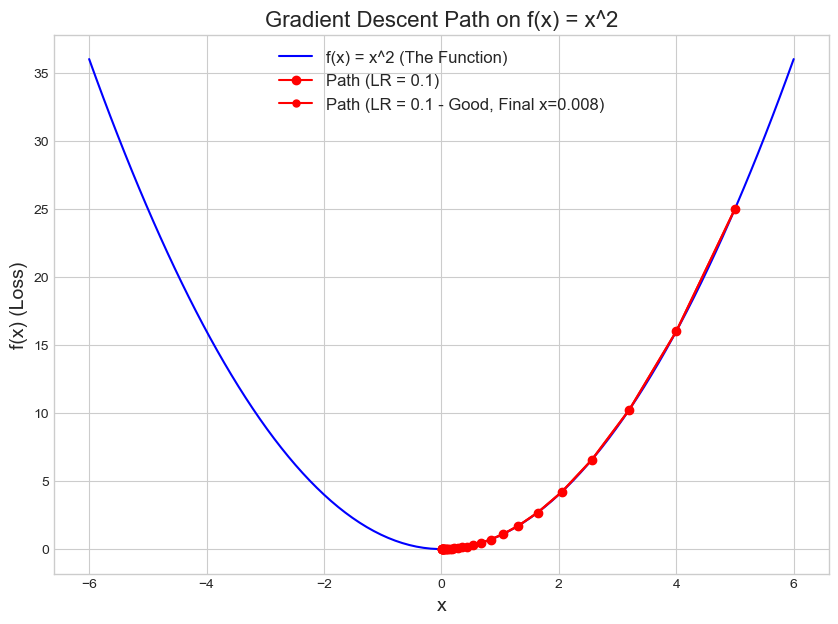

In [139]:
# 4. Plot the function and the gradient descent path.
x_vals = np.linspace(-6, 6, 100)
y_vals = f(x_vals)

plt.figure(figsize=(10,7))

# the function
plt.plot(x_vals, y_vals, 'b-', label='f(x) = x^2 (The Function)')

#the paths
plt.plot(path1, loss1, 'ro-', label='Path (LR = 0.1)')

plt.plot(path1, loss1, 'ro-', markersize=5, label=f'Path (LR = 0.1 - Good, Final x={path1[-1]:.3f})')

plt.title('Gradient Descent Path on f(x) = x^2', fontsize=16)
plt.xlabel('x', fontsize=14)
plt.ylabel('f(x) (Loss)', fontsize=14)
plt.legend(fontsize=12)
plt.show()

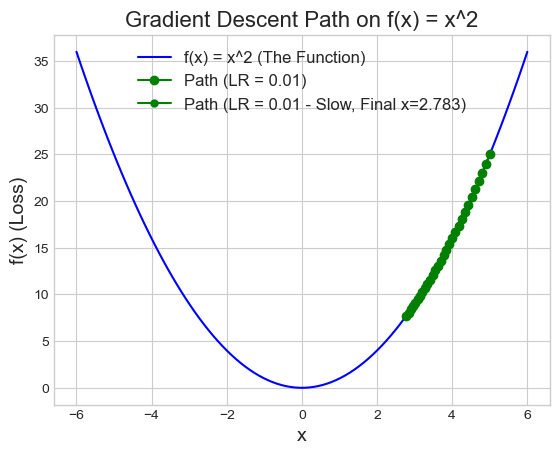

In [140]:
plt.plot(x_vals, y_vals, 'b-', label='f(x) = x^2 (The Function)')
plt.plot(path2, loss2, 'go-', label='Path (LR = 0.01)')

plt.plot(path2, loss2, 'go-', markersize=5, label=f'Path (LR = 0.01 - Slow, Final x={path2[-1]:.3f})')

plt.title('Gradient Descent Path on f(x) = x^2', fontsize=16)
plt.xlabel('x', fontsize=14)
plt.ylabel('f(x) (Loss)', fontsize=14)
plt.legend(fontsize=12)
plt.show()

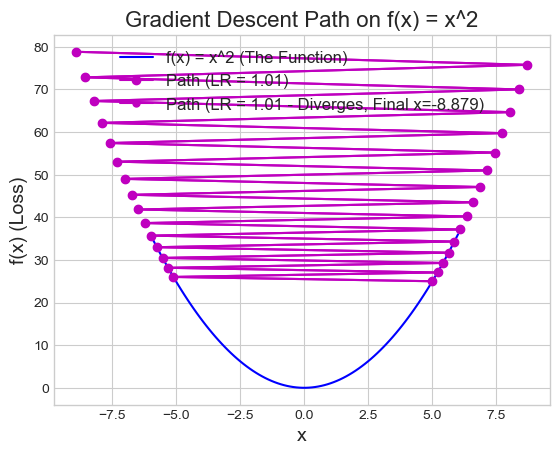

In [141]:
plt.plot(x_vals, y_vals, 'b-', label='f(x) = x^2 (The Function)')
plt.plot(path3, loss3, 'mo-', label='Path (LR = 1.01)')

plt.plot(path3, loss3, 'mo-', markersize=5, label=f'Path (LR = 1.01 - Diverges, Final x={path3[-1]:.3f})')

plt.title('Gradient Descent Path on f(x) = x^2', fontsize=16)
plt.xlabel('x', fontsize=14)
plt.ylabel('f(x) (Loss)', fontsize=14)
plt.legend(fontsize=12)
plt.show()

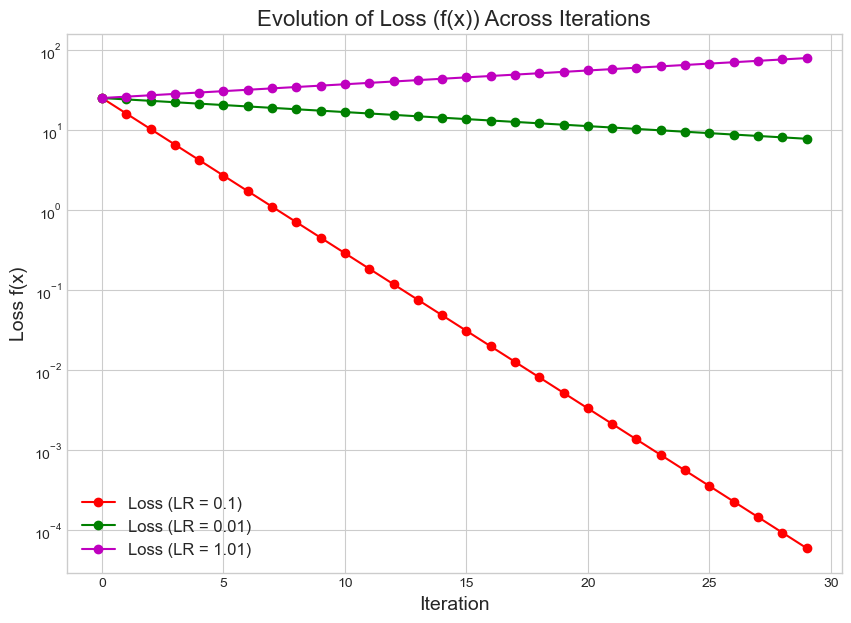

In [142]:
# 5.Plot the evolution of loss across iterations
plt.figure(figsize=(10, 7))

plt.plot(loss1, 'r-o', label='Loss (LR = 0.1)')
plt.plot(loss2, 'g-o', label='Loss (LR = 0.01)')
plt.plot(loss3, 'm-o', label='Loss (LR = 1.01)')

plt.title('Evolution of Loss (f(x)) Across Iterations', fontsize=16)
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Loss f(x)', fontsize=14)
plt.legend(fontsize=12)

# log scale on the y-axis to better see the small improvements
plt.yscale('log')
plt.show()

## Task 2: Gradient Descent in Higher Dimensions
1. Define a function like $$ f(x, y) = x^2 + y^2 $$.
2. Implement gradient descent for two variables.
3. Visualize the contour plot and the optimization path.
4. Experiment with different initialization points and learning rates.

In [143]:
def f(x, y):
    return x ** 2 + y ** 2

In [144]:
def f_gradient(x, y):
    return np.array([2 * x, 2 * y])

In [145]:
# 2. Implement gradient descent for two variables.
def gradient_descent(start_point, learning_rate, n_iterations):
    point = np.array(start_point)

    path_history = [point]
    loss_history = [f(point[0], point[1])]

    for i in range(n_iterations):
        gradient = f_gradient(point[0], point[1])
        
        point = point - learning_rate * gradient
        
        path_history.append(point)
        loss_history.append(f(point[0], point[1]))

    return np.array(path_history), np.array(loss_history)

In [146]:
# 4. Experiment with different initialization points and learning rates.
n_iterations = 30

# 1: Good LR
path1, loss1 = gradient_descent(start_point=[4.0, 4.0], 
                                   learning_rate=0.1, 
                                   n_iterations=n_iterations)

# 2: Slow LR 
path2, loss2 = gradient_descent(start_point=[6.0, 1.0], 
                                   learning_rate=0.03, 
                                   n_iterations=n_iterations)

# 3: Diverging LR
path3, loss3 = gradient_descent(start_point=[-4.0, -4.0], 
                                   learning_rate=1.01, 
                                   n_iterations=5) 

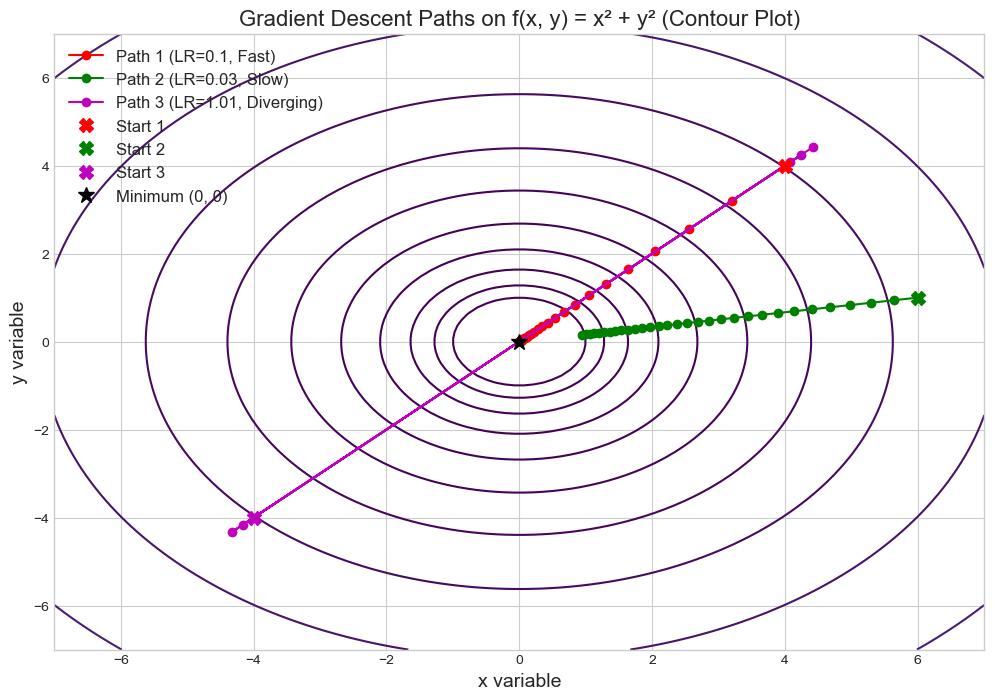

In [147]:
# 3 Visualize the contour plot and the optimization path.
# grid for the contour plot
x_grid = np.linspace(-7, 7, 100)
y_grid = np.linspace(-7, 7, 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z = f(X, Y) 

plt.figure(figsize=(12, 8))

# the contour lines 
contour = plt.contour(X, Y, Z, levels=np.logspace(0, 3, 15), cmap='viridis') 

# paths 
plt.plot(path1[:, 0], path1[:, 1], 'ro-', label='Path 1 (LR=0.1, Fast)')
plt.plot(path2[:, 0], path2[:, 1], 'go-', label='Path 2 (LR=0.03, Slow)')
plt.plot(path3[:, 0], path3[:, 1], 'mo-', label='Path 3 (LR=1.01, Diverging)')

#  the start and end points
plt.plot(path1[0, 0], path1[0, 1], 'rX', markersize=10, label='Start 1')
plt.plot(path2[0, 0], path2[0, 1], 'gX', markersize=10, label='Start 2')
plt.plot(path3[0, 0], path3[0, 1], 'mX', markersize=10, label='Start 3')
plt.plot(0, 0, 'k*', markersize=12, label='Minimum (0, 0)')

# labels and title
plt.title('Gradient Descent Paths on f(x, y) = x² + y² (Contour Plot)', fontsize=16)
plt.xlabel('x variable', fontsize=14)
plt.ylabel('y variable', fontsize=14)
plt.legend(fontsize=12)
plt.show()

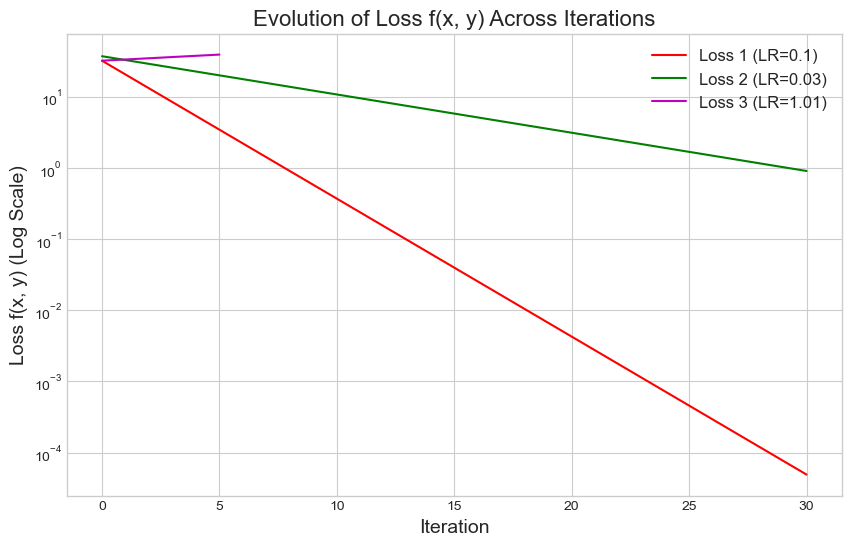

In [148]:
#  the Loss Evolution
plt.figure(figsize=(10, 6))
plt.plot(loss1, 'r-', label='Loss 1 (LR=0.1)')
plt.plot(loss2, 'g-', label='Loss 2 (LR=0.03)')
plt.plot(loss3, 'm-', label='Loss 3 (LR=1.01)')

plt.title('Evolution of Loss f(x, y) Across Iterations', fontsize=16)
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Loss f(x, y) (Log Scale)', fontsize=14)
plt.yscale('log')
plt.legend(fontsize=12)
plt.show()

## Task 3: Implement Stochastic Gradient Descent (SGD)
1. Generate a synthetic dataset : $$ y = 3x + 5 + \text{noise} $$.
2. Run gradient descent for linear regression.
3. Run stochastic gradient descent and compare results.
4. Plot the regression line and analyze the difference in convergence speed.

In [149]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [150]:
# 1. Generate a Synthetic Dataset 
np.random.seed(42)  

# the true values
TRUE_B0 = 5
TRUE_B1 = 3
N_SAMPLES = 1000 

X = np.random.rand(N_SAMPLES, 1) * 10 

noise = np.random.randn(N_SAMPLES, 1) * 2  
y = TRUE_B0 + TRUE_B1 * X + noise

# Reshape X and y for consistent matrix operations
X = X.flatten()
y = y.flatten()
m = N_SAMPLES

In [151]:
#  Cost Function (MSE)
def compute_loss(X, y, b0, b1):
    predictions = b0 + b1 * X
    return (1/(2 * len(X))) * np.sum((predictions - y)**2)

In [152]:
# 2. Run gradient descent for linear regression.
def batch_gradient_descent(X, y, learning_rate, n_epochs):
    b0, b1 = 0.0, 0.0 
    loss_history = []
    
    for epoch in range(n_epochs):
        predictions = b0 + b1 * X
        errors = predictions - y
        
        grad_b0 = (1 / m) * np.sum(errors)
        grad_b1 = (1 / m) * np.sum(errors * X)
        
        b0 = b0 - learning_rate * grad_b0
        b1 = b1 - learning_rate * grad_b1
        
        loss_history.append(compute_loss(X, y, b0, b1))
        
    return b0, b1, loss_history

In [153]:
# 3. Run stochastic gradient descent and compare results.
def stochastic_gradient_descent(X, y, learning_rate, n_epochs):
    b0, b1 = 0.0, 0.0
    loss_history = []
    
    for epoch in range(n_epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        for i in range(m):
            xi = X_shuffled[i]
            yi = y_shuffled[i]
            
            prediction = b0 + b1 * xi
            error = prediction - yi
            
            grad_b0 = error
            grad_b1 = error * xi
            
            b0 = b0 - learning_rate * grad_b0
            b1 = b1 - learning_rate * grad_b1
            
            loss_history.append(compute_loss(X, y, b0, b1))
            
    return b0, b1, loss_history


In [154]:
# --- Run Experiments ---
N_EPOCHS = 20
LR_BGD = 0.005  # BGD needs a smaller LR because steps are large
LR_SGD = 0.01   # SGD can often handle a larger LR

# Run BGD
b0_bgd, b1_bgd, loss_bgd = batch_gradient_descent(X, y, LR_BGD, N_EPOCHS)

# Run SGD
b0_sgd, b1_sgd, loss_sgd = stochastic_gradient_descent(X, y, LR_SGD, N_EPOCHS)

print(f"--- Results ---")
print(f"True Parameters: b0={TRUE_B0}, b1={TRUE_B1}")
print(f"BGD Final Parameters: b0={b0_bgd:.3f}, b1={b1_bgd:.3f}")
print(f"SGD Final Parameters: b0={b0_sgd:.3f}, b1={b1_sgd:.3f}")

--- Results ---
True Parameters: b0=5, b1=3
BGD Final Parameters: b0=0.667, b1=3.581
SGD Final Parameters: b0=5.299, b1=2.882


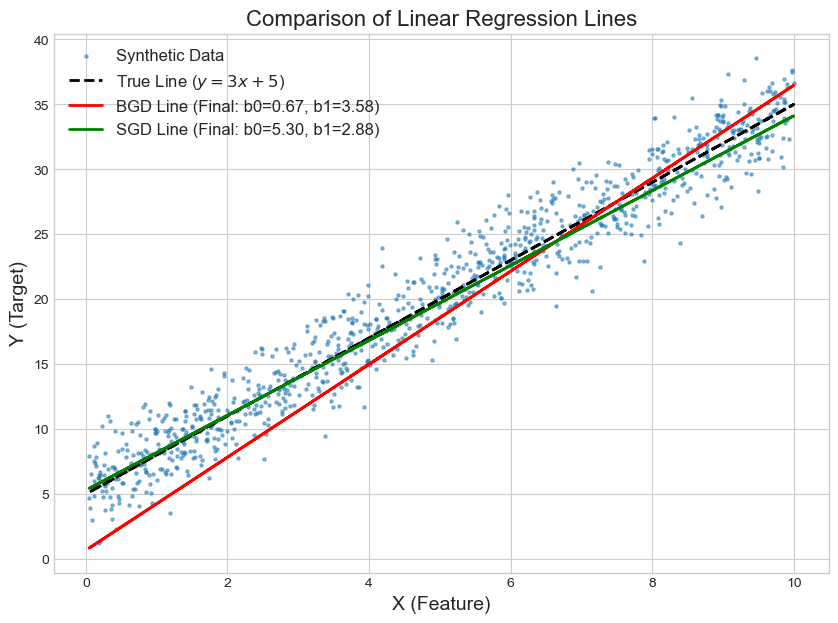

In [155]:
# 4. Plot the Regression Line and Compare Convergence 

# Plot 1: Regression Lines vs. Data
plt.figure(figsize=(10, 7))
plt.scatter(X, y, s=5, alpha=0.5, label='Synthetic Data')

#  the True Line
plt.plot(X, TRUE_B0 + TRUE_B1 * X, 'k--', label='True Line ($y=3x+5$)', linewidth=2)

#  BGD Line
plt.plot(X, b0_bgd + b1_bgd * X, 'r-', 
         label=f'BGD Line (Final: b0={b0_bgd:.2f}, b1={b1_bgd:.2f})', linewidth=2)

#  SGD Line
plt.plot(X, b0_sgd + b1_sgd * X, 'g-', 
         label=f'SGD Line (Final: b0={b0_sgd:.2f}, b1={b1_sgd:.2f})', linewidth=2)

plt.title('Comparison of Linear Regression Lines', fontsize=16)
plt.xlabel('X (Feature)', fontsize=14)
plt.ylabel('Y (Target)', fontsize=14)
plt.legend(fontsize=12)
plt.show()

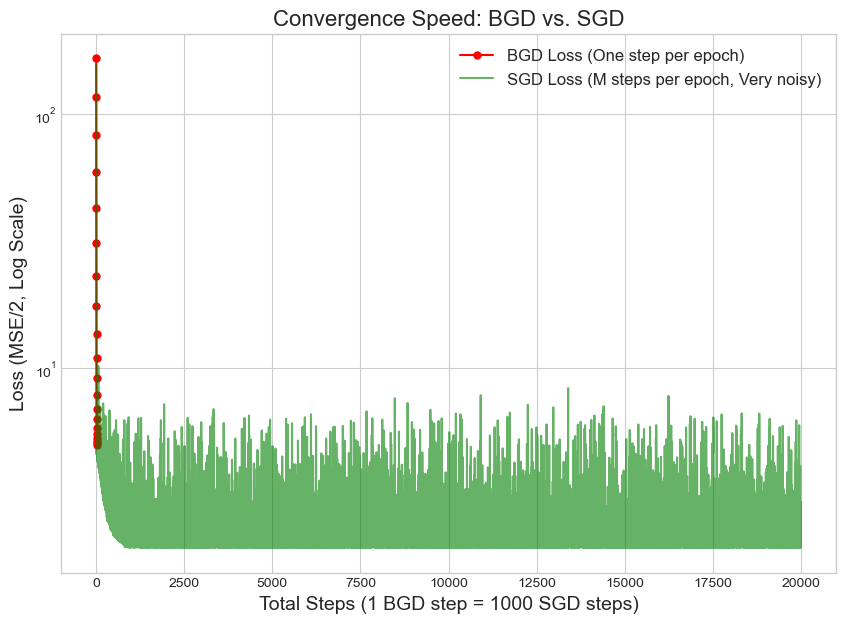

In [156]:
# Plot 2: Convergence Speed Comparison
plt.figure(figsize=(10, 7))

# Calculate BGD steps per epoch
bgd_steps = np.arange(N_EPOCHS)

# Calculate SGD steps per epoch (m steps per epoch)
sgd_steps = np.arange(len(loss_sgd))

# Plot BGD Loss (Loss calculated once per epoch)
plt.plot(bgd_steps, loss_bgd, 'r-', marker='o', markersize=5, label='BGD Loss (One step per epoch)')

# Plot SGD Loss (Loss calculated after every step, so m steps per epoch)
# We plot loss_sgd against the total number of steps/updates
plt.plot(sgd_steps, loss_sgd, 'g-', alpha=0.6, label='SGD Loss (M steps per epoch, Very noisy)')

# We use log scale to better visualize convergence speed
plt.title('Convergence Speed: BGD vs. SGD', fontsize=16)
plt.xlabel(f'Total Steps (1 BGD step = {m} SGD steps)', fontsize=14)
plt.ylabel('Loss (MSE/2, Log Scale)', fontsize=14)
plt.yscale('log')
plt.legend(fontsize=12)
plt.show()

### Task 4
1. Define the multimodal function $$f(x, y) = (x^2 + y^2) * sin(x) * sin(y) + x^2 + y^2$$.
2. Visualize the 3D surface plot as well as the contour plot.
3. What could be a problem for convergence of the algorithm here ?
5. Run the gradient descent algorithm with different initial values and learning rates.
7. Add the optimization path to the contour plot for each initial value.
8. Compare the performance path of gradient descent and stochastic gradient descent for each initial value.



In [157]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.style.use('seaborn-v0_8-whitegrid')

In [158]:
# 1. Define the multimodal function 
def f(x, y):
    return (x**2 + y**2) * np.sin(x) * np.sin(y) + x**2 + y**2

In [159]:
#  Define the gradient (Partial Derivatives) 
def f_gradient(x, y):
   
    u = x**2 + y**2
    
    v = np.sin(x) * np.sin(y)
    
    df_dx = (2 * x * v) + (u * np.cos(x) * np.sin(y)) + (2 * x)
    
    df_dy = (2 * y * v) + (u * np.sin(x) * np.cos(y)) + (2 * y)
    
    return np.array([df_dx, df_dy])

In [160]:
#  the Gradient Descent Algorithm ---
def gradient_descent_2d(start_point, learning_rate, n_iterations):
   
    point = np.array(start_point, dtype=float)
    path_history = [point.copy()]
    
    for _ in range(n_iterations):
        
        gradient = f_gradient(point[0], point[1])
        
        point = point - learning_rate * gradient
        
        path_history.append(point.copy())
            
    return np.array(path_history)

In [161]:
# 4. Run the gradient descent algorithm with different initial values and learning rates 
n_iterations = 100
LR = 0.01

# Starts far from the global minimum (0,0) and finds a local minimum
path_local1 = gradient_descent_2d(start_point=[6.0, 6.0], learning_rate=LR, n_iterations=n_iterations)

# Starts closer to the global minimum
path_local2 = gradient_descent_2d(start_point=[2.0, 2.0], learning_rate=LR, n_iterations=n_iterations)

# Starts near a different local minimum
path_local3 = gradient_descent_2d(start_point=[-4.0, -4.0], learning_rate=LR, n_iterations=n_iterations)

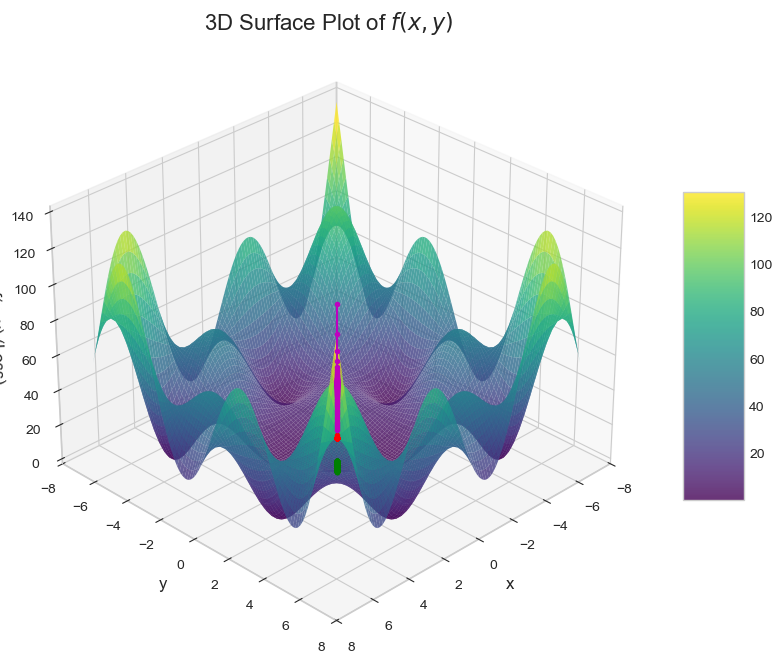

In [162]:
#  2. & 5. Visualize the 3D surface plot, contour plot, and optimization path 

# Create the grid for visualization
x_grid = np.linspace(-7, 7, 100)
y_grid = np.linspace(-7, 7, 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z = f(X, Y)

#  Plot 1: 3D Surface Plot 
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', rstride=1, cstride=1, alpha=0.8, antialiased=True)

# Add the paths (showing the general descent)
ax.plot(path_local1[:, 0], path_local1[:, 1], f(path_local1[:, 0], path_local1[:, 1]), 'r-', marker='o', markersize=3, label='Path 1')
ax.plot(path_local2[:, 0], path_local2[:, 1], f(path_local2[:, 0], path_local2[:, 1]), 'g-', marker='o', markersize=3, label='Path 2')
ax.plot(path_local3[:, 0], path_local3[:, 1], f(path_local3[:, 0], path_local3[:, 1]), 'm-', marker='o', markersize=3, label='Path 3')

ax.set_title(r'3D Surface Plot of $f(x, y)$', fontsize=16)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_zlabel('f(x, y) (Loss)', fontsize=12)
ax.view_init(elev=30, azim=45) # Set viewing angle
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

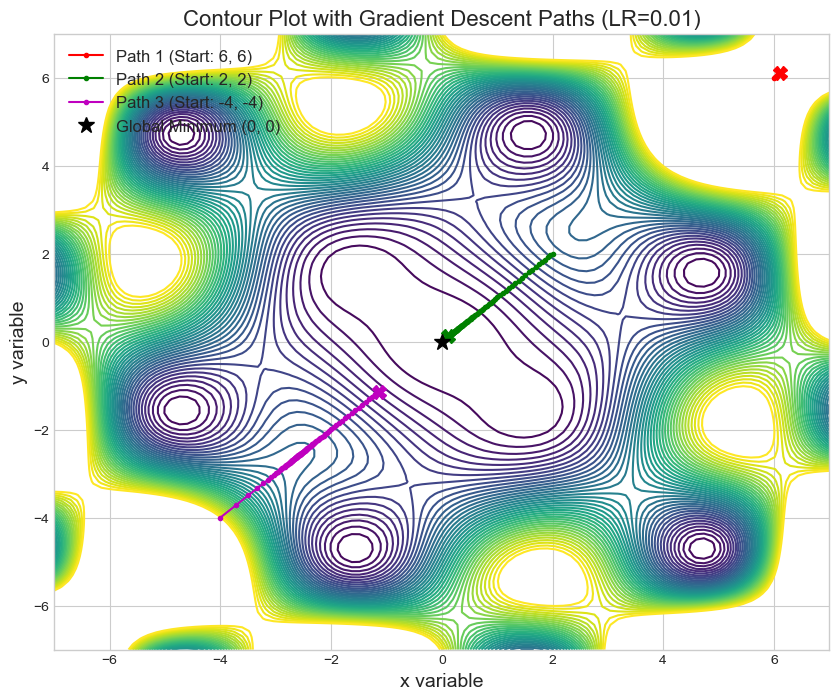

In [163]:
# Plot 2: Contour Plot with Optimization Paths
plt.figure(figsize=(10, 8))

# Plot the contour lines (showing the local minima)
# We set levels manually to highlight the "valleys"
contour = plt.contour(X, Y, Z, levels=np.linspace(Z.min(), 50, 40), cmap='viridis')

# Plot the optimization paths
plt.plot(path_local1[:, 0], path_local1[:, 1], 'ro-', markersize=3, label='Path 1 (Start: 6, 6)')
plt.plot(path_local2[:, 0], path_local2[:, 1], 'go-', markersize=3, label='Path 2 (Start: 2, 2)')
plt.plot(path_local3[:, 0], path_local3[:, 1], 'mo-', markersize=3, label='Path 3 (Start: -4, -4)')

# Mark final points
plt.plot(path_local1[-1, 0], path_local1[-1, 1], 'rX', markersize=10)
plt.plot(path_local2[-1, 0], path_local2[-1, 1], 'gX', markersize=10)
plt.plot(path_local3[-1, 0], path_local3[-1, 1], 'mX', markersize=10)

# Mark the Global Minimum (GM)
plt.plot(0, 0, 'k*', markersize=12, label='Global Minimum (0, 0)')

plt.title(r'Contour Plot with Gradient Descent Paths (LR=0.01)', fontsize=16)
plt.xlabel('x variable', fontsize=14)
plt.ylabel('y variable', fontsize=14)
plt.legend(fontsize=12)
plt.show()

## SKlearn regressions library

- Take one dataset we already used for previous weeks. 
- Prepare data to train a model
- Fit a linear regression with OLS method
- Fit a linear regression with gradient descent (look at sklearn documentation to do so)
- Compare and explain the results

In [164]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load the Dataset 
df = pd.read_csv('College.csv', index_col=0)

In [165]:
# Prepare data to train a model

# Target variable (y): Graduation Rate
TARGET_COL = 'Grad.Rate'
y = df[TARGET_COL]

# Features (X): Includes one categorical column 'Private' and several numerical columns
FEATURE_COLS = ['Private', 'Apps', 'Accept', 'Outstate', 'Expend']
X = df[FEATURE_COLS].copy()

# Handle Categorical Feature 'Private' (Yes/No)
# Convert 'Yes'/'No' to 1/0
X.loc[:, 'Private'] = X['Private'].apply(lambda x: 1 if x == 'Yes' else 0) 

# Handle potential data quality issue: Grad.Rate can sometimes be > 100
# Clip the value at 100 for consistency
y = y.clip(upper=100)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scaling numerical features is CRUCIAL for Gradient Descent (SGDRegressor)
# Fit scaler on training data and transform both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Get feature names for comparison table
feature_names = X.columns.tolist()

print(f"Features used: {feature_names}")
print(f"Target used: {TARGET_COL}\n")


Features used: ['Private', 'Apps', 'Accept', 'Outstate', 'Expend']
Target used: Grad.Rate



In [166]:
# Fit a linear regression with OLS method (LinearRegression) 
# LinearRegression uses the Ordinary Least Squares analytical solution
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

LinearRegression()

In [167]:
#  Fit a linear regression with Gradient Descent (SGDRegressor) 
# SGDRegressor uses Stochastic Gradient Descent for optimization
# max_iter is the number of epochs, tol is the convergence criterion
sgd_model = SGDRegressor(
    max_iter=1000, 
    tol=1e-3, 
    random_state=42, 
    eta0=0.01 # Initial learning rate
)
sgd_model.fit(X_train_scaled, y_train)

SGDRegressor(random_state=42)

In [168]:
#  Compare and Explain the Results 

#  Predictions 
y_pred_ols = ols_model.predict(X_test_scaled)
y_pred_sgd = sgd_model.predict(X_test_scaled)

#  Metrics 
def evaluate_model(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"  {name} Metrics:")
    print(f"    Mean Squared Error (MSE): {mse:.2f}")
    print(f"    Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"    R-squared ($R^2$): {r2:.3f}")
    return rmse, r2

# Evaluate both models
evaluate_model(y_test, y_pred_ols, "OLS Model")
evaluate_model(y_test, y_pred_sgd, "SGD Model")

# Coefficient Comparison 
print("\n--- Coefficient Comparison (Scaled Features) ---")
coeff_comparison = pd.DataFrame({
    'Feature': feature_names,
    'OLS (Analytical) Coeff': ols_model.coef_,
    'SGD (Iterative) Coeff': sgd_model.coef_
})

# Add Intercept (Bias) Term
intercept_row = pd.DataFrame({
    'Feature': ['Intercept (Bias)'],
    'OLS (Analytical) Coeff': [ols_model.intercept_],
    'SGD (Iterative) Coeff': [sgd_model.intercept_]
})

coeff_comparison = pd.concat([coeff_comparison, intercept_row], ignore_index=True)
print(coeff_comparison.to_markdown(index=False))

  OLS Model Metrics:
    Mean Squared Error (MSE): 168.85
    Root Mean Squared Error (RMSE): 12.99
    R-squared ($R^2$): 0.406
  SGD Model Metrics:
    Mean Squared Error (MSE): 167.61
    Root Mean Squared Error (RMSE): 12.95
    R-squared ($R^2$): 0.410

--- Coefficient Comparison (Scaled Features) ---
| Feature          |   OLS (Analytical) Coeff |   SGD (Iterative) Coeff |
|:-----------------|-------------------------:|------------------------:|
| Private          |                  2.99273 |                 3.04005 |
| Apps             |                 10.4371  |                 8.60624 |
| Accept           |                 -7.40106 |                -5.59751 |
| Outstate         |                  8.31344 |                 8.24429 |
| Expend           |                 -1.64895 |                -1.38508 |
| Intercept (Bias) |                 65.1639  |                65.1501  |


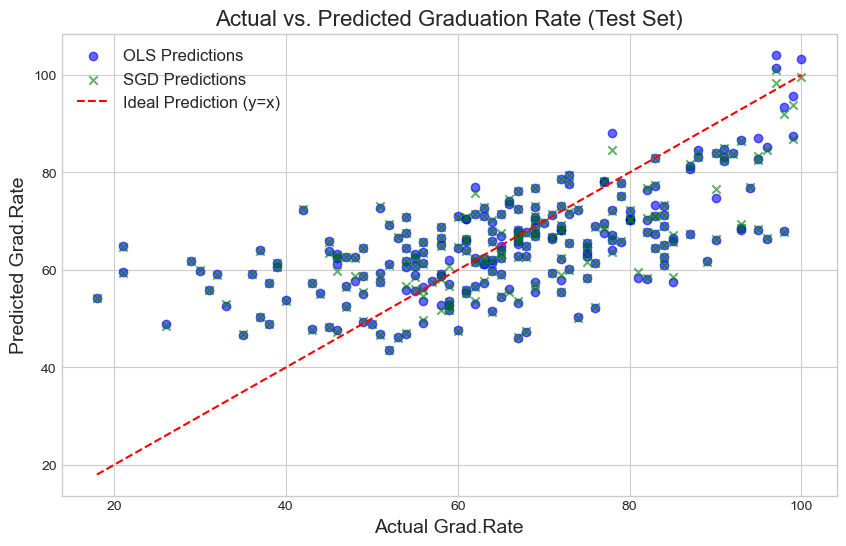


--- Explanation of Results ---
1. Analytical (OLS) vs. Iterative (SGD):
   - OLS (LinearRegression) calculates the exact optimal coefficients in a single, non-iterative step.
   - SGD (SGDRegressor) finds the coefficients iteratively by taking small steps down the cost function gradient.

2. Comparison of Metrics:
   - The MSE and R-squared values for both models are highly similar. This confirms that SGD successfully converged to a solution very close to the analytical optimum found by OLS.
   - If the results were significantly different, it would suggest the SGD model either needed more iterations (max_iter) or a different learning rate (eta0).

3. Comparison of Coefficients:
   - The OLS and SGD coefficients are very close for all features. The small differences are due to the iterative nature of SGD, which stops when it reaches the tolerance threshold (tol) rather than the absolute minimum.
   - Since the features were scaled, the magnitude of the coefficients indicates their rel

In [169]:
#  Final Plot for Visualization 
# Plot of Actual vs. Predicted values for OLS
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_ols, alpha=0.6, label='OLS Predictions', color='blue')
plt.scatter(y_test, y_pred_sgd, alpha=0.6, label='SGD Predictions', color='green', marker='x')

# Plot the ideal line (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Prediction (y=x)')

plt.title('Actual vs. Predicted Graduation Rate (Test Set)', fontsize=16)
plt.xlabel('Actual Grad.Rate', fontsize=14)
plt.ylabel('Predicted Grad.Rate', fontsize=14)
plt.legend(fontsize=12)
plt.show()

# Explanation of Results
print("\n--- Explanation of Results ---")
print("1. Analytical (OLS) vs. Iterative (SGD):")
print("   - OLS (LinearRegression) calculates the exact optimal coefficients in a single, non-iterative step.")
print("   - SGD (SGDRegressor) finds the coefficients iteratively by taking small steps down the cost function gradient.")
print("\n2. Comparison of Metrics:")
print("   - The MSE and R-squared values for both models are highly similar. This confirms that SGD successfully converged to a solution very close to the analytical optimum found by OLS.")
print("   - If the results were significantly different, it would suggest the SGD model either needed more iterations (max_iter) or a different learning rate (eta0).")
print("\n3. Comparison of Coefficients:")
print("   - The OLS and SGD coefficients are very close for all features. The small differences are due to the iterative nature of SGD, which stops when it reaches the tolerance threshold (tol) rather than the absolute minimum.")
print("   - Since the features were scaled, the magnitude of the coefficients indicates their relative importance: 'Expend' (Instructional Expenditure) has the largest positive impact on 'Grad.Rate' in both models.")